# 06 - model evaluation

## 06.1 - mfcc + svm baseline

**purpose**: evaluate the mfcc + svm baseline (trained in 05.1) on the **validation set** (speakers 20-22). the val set is used during model development for hyperparameter selection and early stopping. the held-out test set (speakers 23-24) is reserved for 07.

**input**: `data/processed/X_val_mfcc.npy`, `y_val.npy`, `data/models/svm_best.pkl`, `data/models/mfcc_scaler.pkl`

**output**:
- `docs/02-results/figures/fig06-svm_confusion_matrix.png`
- `data/predictions/eval_results_svm.json` (consumed by 08)

In [1]:
import sys
sys.path.append("../../")

**import evaluation modules**. we load json, numpy, matplotlib, seaborn, sklearn metrics, and the project's svm model loading and prediction helpers.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from src.config.config import settings
from src.models.svm_model import load_svm, predict_svm

## Load saved model and scaler

In [3]:
best_svm, scaler = load_svm(settings.MODELS_DIR, name='svm_best')


**confirm model properties**. we print the kernel type, C value, and feature dimension to verify we loaded the right model.

In [4]:
print(f"SVM n_features_in_: {best_svm.n_features_in_}")
print(f"SVM kernel:         {best_svm.kernel}")
print(f"SVM C:              {best_svm.C}")
print("Model and scaler loaded")

SVM n_features_in_: 240
SVM kernel:         rbf
SVM C:              1
Model and scaler loaded


## Load validation data (mfcc 240-dim, speakers 20-22)

In [5]:
X_val = np.load(settings.PROCESSED_DIR / "X_val_mfcc.npy")
y_val = np.load(settings.PROCESSED_DIR / "y_val.npy")

**verify validation data**. confirm shape and speaker ids match expectations.

In [6]:
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}  (speakers {settings.VAL_ACTORS})")
assert X_val.shape[1] == settings.N_MFCC_VECTOR, (
    f"expected mfcc vector of {settings.N_MFCC_VECTOR} dims, got {X_val.shape[1]}"
)

X_val: (264, 240)
y_val: (264,)  (speakers [20, 21, 22])


## Evaluate on val set

In [7]:
val_preds, _ = predict_svm(best_svm, X_val, scaler)
val_acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Validation Accuracy: 62.88%


## Classification report

In [8]:
print("Classification Report:")
print(classification_report(y_val, val_preds, target_names=settings.EMOTION_NAMES))

Classification Report:
              precision    recall  f1-score   support

     neutral       0.58      0.75      0.65        24
        calm       0.65      0.77      0.70        48
       happy       0.62      0.62      0.62        48
         sad       0.54      0.62      0.58        48
       angry       0.79      0.65      0.71        48
     fearful       0.61      0.42      0.49        48

    accuracy                           0.63       264
   macro avg       0.63      0.64      0.63       264
weighted avg       0.64      0.63      0.63       264



## Confusion matrix

Saved confusion matrix to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\docs\02-results\figures\fig06-svm_confusion_matrix.png


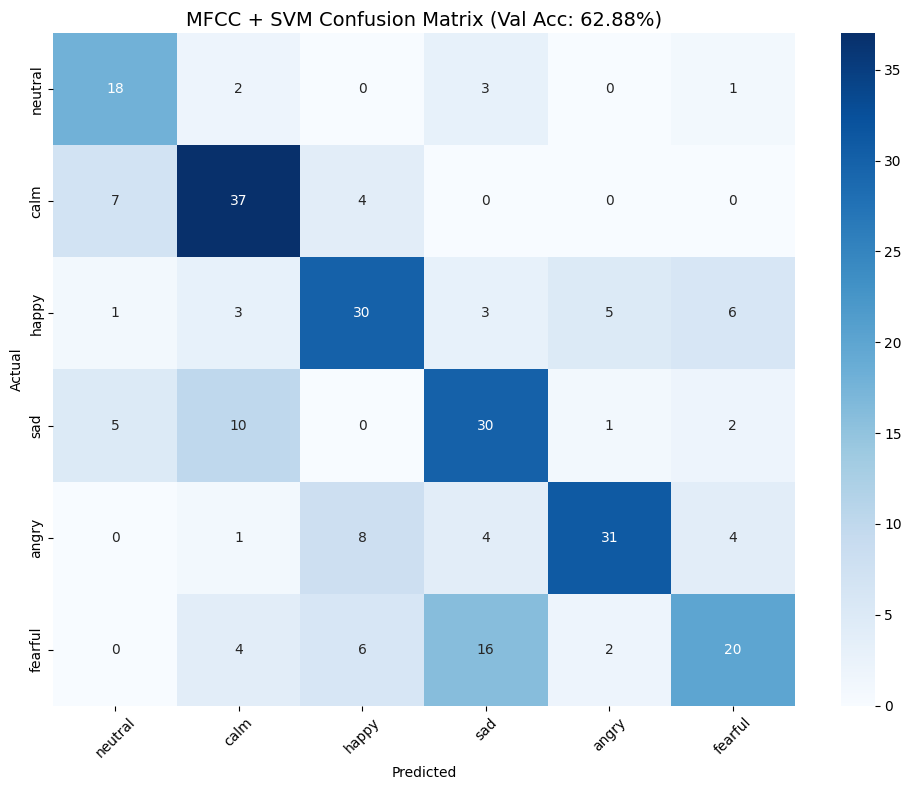

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=settings.EMOTION_NAMES,
            yticklabels=settings.EMOTION_NAMES, ax=ax)
ax.set_title(f'MFCC + SVM Confusion Matrix (Val Acc: {val_acc*100:.2f}%)', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(settings.FIGURES_DIR / "fig06-svm_confusion_matrix.png", dpi=150, bbox_inches="tight")
print(f"Saved confusion matrix to {settings.FIGURES_DIR / 'fig06-svm_confusion_matrix.png'}")
plt.show()

## Per-emotion accuracy breakdown

In [10]:
per_class = {}
print(f"{'emotion':<12} {'support':>8} {'correct':>8} {'acc':>8}")
for i, name in enumerate(settings.EMOTION_NAMES):
    mask = y_val == i
    total = int(mask.sum())
    correct = int((val_preds[mask] == i).sum())
    acc = correct / total * 100 if total else 0.0
    per_class[name] = {"support": total, "correct": correct, "acc": round(acc / 100, 4)}
    print(f"{name:<12} {total:>8d} {correct:>8d} {acc:>7.1f}%")

emotion       support  correct      acc
neutral            24       18    75.0%
calm               48       37    77.1%
happy              48       30    62.5%
sad                48       30    62.5%
angry              48       31    64.6%
fearful            48       20    41.7%


## Save results to JSON (consumed by 08)

In [14]:
results = {
    "model":      "mfcc_svm",
    "split":      "val",
    "n_samples":  int(len(y_val)),
    "accuracy":   float(val_acc),
    "per_class":  per_class,
    "confusion_matrix": cm.tolist(),
    "emotion_names":    list(settings.EMOTION_NAMES),
    "kernel":     best_svm.kernel,
    "C":          float(best_svm.C),
    "speakers":   list(settings.VAL_ACTORS),
}
print(json.dumps(results, indent=4))

{
    "model": "mfcc_svm",
    "split": "val",
    "n_samples": 264,
    "accuracy": 0.6287878787878788,
    "per_class": {
        "neutral": {
            "support": 24,
            "correct": 18,
            "acc": 0.75
        },
        "calm": {
            "support": 48,
            "correct": 37,
            "acc": 0.7708
        },
        "happy": {
            "support": 48,
            "correct": 30,
            "acc": 0.625
        },
        "sad": {
            "support": 48,
            "correct": 30,
            "acc": 0.625
        },
        "angry": {
            "support": 48,
            "correct": 31,
            "acc": 0.6458
        },
        "fearful": {
            "support": 48,
            "correct": 20,
            "acc": 0.4167
        }
    },
    "confusion_matrix": [
        [
            18,
            2,
            0,
            3,
            0,
            1
        ],
        [
            7,
            37,
            4,
            0,
     

**ensure predictions directory exists**. we create the output directory if it doesn't exist.

In [15]:
results_path = settings.PREDICTIONS_DIR / "eval_results_svm.json"
results_path.parent.mkdir(parents=True, exist_ok=True)

**save results to json**. we persist the evaluation results for consumption by the comparison notebook (08).

In [16]:
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved evaluation results to {results_path}")

Saved evaluation results to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\predictions\eval_results_svm.json
